In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().absolute().parent))


In [2]:
# Standard library imports
import sys
from pathlib import Path

# Third-party scientific computing
import numpy as np
import pandas as pd

# Deep learning frameworks
import torch
import pytorch_lightning as pl

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.pipeline import Pipeline

# Local imports - data processing
from src.data_models.caravanify import Caravanify, CaravanifyConfig
from src.data_models.datamodule import HydroDataModule
from src.preprocessing.grouped import GroupedTransformer
from src.preprocessing.standard_scale import StandardScaleTransformer

# # Local imports - models and evaluation
# from src.models.TSMixer import LitTSMixer, TSMixerConfig
from src.models.dummy import RepeatLastValuesConfig, LitRepeatLastValues

from src.models.tft import TFTConfig, LitTFT
from src.models.ealstm import EALSTMConfig, LitEALSTM
from src.models.tide import TiDEConfig, LitTiDE

from src.model_evaluation.evaluators import TSForecastEvaluator
from src.model_evaluation.visualization import plot_basin_map, plot_metric_boxplot, plot_metric_cdf, plot_rolling_forecast

# Append parent directory to path (if needed)
sys.path.append(str(Path().absolute().parent))

---

# Load the trained model

In [3]:
# BENCHMARK_INPUT_LENGTH: int = 33
# BENCHMARK_OUTPUT_LENGTH: int = 10
# BENCHMARK_HIDDEN_SIZE: int = 127
# BENCHMARK_DROPOUT: float = 0.2
# BENCHMARK_NUM_LAYERS: int = 15
# BENCHMARK_STATIC_EMBEDDING_SIZE: int = 16
# BENCHMARK_LEARNING_RATE: float = 6.5e-5
# BENCHMARK_FUSION_METHOD: str = "add"  # Options: "add" or "concat"

# # similarity_based model configuration
# CHALLENGER_INPUT_LENGTH: int = 256
# CHALLENGER_OUTPUT_LENGTH: int = 10
# CHALLENGER_HIDDEN_SIZE: int = 128
# CHALLENGER_DROPOUT: float = 0.3
# CHALLENGER_NUM_LAYERS: int = 13
# CHALLENGER_STATIC_EMBEDDING_SIZE: int = 9
# CHALLENGER_LEARNING_RATE: float = 2e-5

# benchmark_config = TSMixerConfig(
#     input_len=BENCHMARK_INPUT_LENGTH,
#     input_size=len(FORCING_FEATURES) + 1,  # +1 for target
#     output_len=BENCHMARK_OUTPUT_LENGTH,
#     static_size=len(STATIC_FEATURES) - 1,  # -1 for gauge_id
#     future_input_size=len(FORCING_FEATURES),  # Add future forcing size
#     hidden_size=BENCHMARK_HIDDEN_SIZE,
#     static_embedding_size=BENCHMARK_STATIC_EMBEDDING_SIZE,
#     num_layers=BENCHMARK_NUM_LAYERS,
#     dropout=BENCHMARK_DROPOUT,
#     learning_rate=BENCHMARK_LEARNING_RATE,
#     group_identifier="gauge_id",  # Define GROUP_IDENTIFIER if necessary
#     lr_scheduler_patience=5,  # Define LR_SCHEDULER_PATIENCE if necessary
#     lr_scheduler_factor=0.5,  # Define LR_SCHEDULER_FACTOR if necessary
#     fusion_method="add",  # Replace FUSION_METHOD with an appropriate value
# )

# challenger_config = TSMixerConfig(
#     input_len=CHALLENGER_INPUT_LENGTH,
#     input_size=len(FORCING_FEATURES) + 1,  # +1 for target
#     output_len=CHALLENGER_OUTPUT_LENGTH,
#     static_size=len(STATIC_FEATURES) - 1,  # -1 for gauge_id
#     future_input_size=len(FORCING_FEATURES),  # Add future forcing size
#     hidden_size=CHALLENGER_HIDDEN_SIZE,
#     static_embedding_size=CHALLENGER_STATIC_EMBEDDING_SIZE,
#     num_layers=CHALLENGER_NUM_LAYERS,
#     dropout=CHALLENGER_DROPOUT,
#     learning_rate=CHALLENGER_LEARNING_RATE,
#     group_identifier="gauge_id",  # Define GROUP_IDENTIFIER if necessary
#     lr_scheduler_patience=5,  # Define LR_SCHEDULER_PATIENCE if necessary
#     lr_scheduler_factor=0.5,  # Define LR_SCHEDULER_FACTOR if necessary
#     fusion_method="add",  # Replace FUSION_METHOD with an appropriate value
# )

In [4]:
TFT_ADD_RELATIVE_INDEX = False
TFT_ATTENTION_DROPOUT = 0.23555278841790406
TFT_CONTEXT_LENGTH_RATIO = 0.8037724259507192
TFT_DROPOUT = 0.14561457009902096
TFT_ENCODER_LAYERS = 3
TFT_FUTURE_INPUT_SIZE = 9
TFT_GROUP_IDENTIFIER = "gauge_id"
TFT_HIDDEN_CONTINUOUS_SIZE = 72
TFT_HIDDEN_SIZE = 72
TFT_INPUT_LEN = 206
TFT_INPUT_SIZE = 10
TFT_LEARNING_RATE = 0.00016738085788752134
TFT_LSTM_LAYERS = 1
TFT_NUM_ATTENTION_HEADS = 2
TFT_OUTPUT_LEN = 10
TFT_QUANTILES = [0.1, 0.5, 0.9]
TFT_SCHEDULER_FACTOR = 0.5
TFT_SCHEDULER_PATIENCE = 5
TFT_STATIC_SIZE = 10
TFT_USE_EMBEDDING_FOR_CONTEXT = True
TFT_USE_REVIN = True

EALSTM_BIAS = True
EALSTM_BIDIRECTIONAL = True
EALSTM_BIDIRECTIONAL_FUSION = "concat"
EALSTM_DROPOUT = 0.4330880728874676
EALSTM_FUTURE_HIDDEN_SIZE = 45  
EALSTM_FUTURE_INPUT_SIZE = 9
EALSTM_FUTURE_LAYERS = 3
EALSTM_GROUP_IDENTIFIER = "gauge_id"
EALSTM_HIDDEN_SIZE = 45 
EALSTM_INPUT_LEN = 82 
EALSTM_INPUT_SIZE = 10
EALSTM_LEARNING_RATE = 0.00015930522616241006
EALSTM_NUM_LAYERS = 3  
EALSTM_OUTPUT_LEN = 10
EALSTM_SCHEDULER_FACTOR = 0.5
EALSTM_SCHEDULER_PATIENCE = 5
EALSTM_STATIC_SIZE = 10

TIDE_HIDDEN_SIZE = 101
TIDE_INPUT_LEN = 70
TIDE_DROPOUT = 0.3803925243084487
TIDE_LEARNING_RATE = 0.0001326033192269654
TIDE_NUM_ENCODER_LAYERS = 3
TIDE_NUM_DECODER_LAYERS = 2
TIDE_DECODER_OUTPUT_SIZE = 21
TIDE_TEMPORAL_DECODER_HIDDEN_SIZE = 36
TIDE_USE_LAYER_NORM = False
TIDE_FUTURE_INPUT_SIZE = 9
TIDE_STATIC_SIZE = 10
TIDE_INPUT_SIZE = 10
TIDE_OUTPUT_LEN = 10
TIDE_GROUP_IDENTIFIER = "gauge_id"
TIDE_SCHEDULER_FACTOR = 0.5
TIDE_SCHEDULER_PATIENCE = 5


STATIC_FEATURES = [
    "gauge_id",
    "p_mean",
    "area",
    "ele_mt_sav",
    "high_prec_dur",
    "frac_snow",
    "high_prec_freq",
    "slp_dg_sav",
    "cly_pc_sav",
    "aridity_ERA5_LAND",
    "aridity_FAO_PM",
]

FORCING_FEATURES = [
    "snow_depth_water_equivalent_mean",
    "surface_net_solar_radiation_mean",
    "surface_net_thermal_radiation_mean",
    "potential_evaporation_sum_ERA5_LAND",
    "potential_evaporation_sum_FAO_PENMAN_MONTEITH",
    "temperature_2m_mean",
    "temperature_2m_min",
    "temperature_2m_max",
    "total_precipitation_sum",
]

TARGET = "streamflow"


TFT_config = TFTConfig(
    input_len=TFT_INPUT_LEN,
    input_size=TFT_INPUT_SIZE,
    output_len=TFT_OUTPUT_LEN,
    static_size=TFT_STATIC_SIZE,
    future_input_size=TFT_FUTURE_INPUT_SIZE,
    hidden_size=TFT_HIDDEN_SIZE,
    hidden_continuous_size=TFT_HIDDEN_CONTINUOUS_SIZE,
    num_attention_heads=TFT_NUM_ATTENTION_HEADS,
    encoder_layers=TFT_ENCODER_LAYERS,
    lstm_layers=TFT_LSTM_LAYERS,
    dropout=TFT_DROPOUT,
    attn_dropout=TFT_ATTENTION_DROPOUT,
    use_revin=TFT_USE_REVIN,
    use_embedding_for_context=TFT_USE_EMBEDDING_FOR_CONTEXT,
    context_length_ratio=TFT_CONTEXT_LENGTH_RATIO,
    quantiles=TFT_QUANTILES,
    learning_rate=TFT_LEARNING_RATE,
    group_identifier=TFT_GROUP_IDENTIFIER,
)

EALSTM_config = EALSTMConfig(
    input_len=EALSTM_INPUT_LEN,
    input_size=EALSTM_INPUT_SIZE,
    output_len=EALSTM_OUTPUT_LEN,
    static_size=EALSTM_STATIC_SIZE,
    future_input_size=EALSTM_FUTURE_INPUT_SIZE,
    hidden_size=EALSTM_HIDDEN_SIZE,
    future_hidden_size=EALSTM_FUTURE_HIDDEN_SIZE,
    num_layers=EALSTM_NUM_LAYERS,
    future_layers=EALSTM_FUTURE_LAYERS,
    dropout=EALSTM_DROPOUT,
    bidirectional=EALSTM_BIDIRECTIONAL,
    bidirectional_fusion=EALSTM_BIDIRECTIONAL_FUSION,
    learning_rate=EALSTM_LEARNING_RATE,
    group_identifier=EALSTM_GROUP_IDENTIFIER,
)


TiDE_config = TiDEConfig(
    input_len=TIDE_INPUT_LEN,
    input_size=TIDE_INPUT_SIZE,
    output_len=TIDE_OUTPUT_LEN,
    static_size=TIDE_STATIC_SIZE,
    future_input_size=TIDE_FUTURE_INPUT_SIZE,
    hidden_size=TIDE_HIDDEN_SIZE,
    num_encoder_layers=TIDE_NUM_ENCODER_LAYERS,
    num_decoder_layers=TIDE_NUM_DECODER_LAYERS,
    temporal_decoder_hidden_size=TIDE_TEMPORAL_DECODER_HIDDEN_SIZE,
    dropout=TIDE_DROPOUT,
    use_layer_norm=TIDE_USE_LAYER_NORM,
    learning_rate=TIDE_LEARNING_RATE,
    group_identifier=TIDE_GROUP_IDENTIFIER,
)

dummy_config = RepeatLastValuesConfig(
    input_len=TIDE_INPUT_LEN,
    input_size=TIDE_INPUT_SIZE,
    output_len=TIDE_OUTPUT_LEN,
)


In [5]:
config = CaravanifyConfig(
    attributes_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/attributes",
    timeseries_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/timeseries/csv",
    shapefile_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/shapefiles",
    # human_influence_path="/Users/cooper/Desktop/CAMELS-CH/src/human_influence_index/results/human_influence_classification.csv",
    gauge_id_prefix="CA",
    use_hydroatlas_attributes=True,
    use_caravan_attributes=True,
    use_other_attributes=True,
)

ca_caravan = Caravanify(config)
ca_basins = ca_caravan.get_all_gauge_ids()

print(f"Found {len(ca_basins)} total CA basins")

ca_caravan.load_stations(ca_basins)

# Prepare data frames
ts_columns = FORCING_FEATURES + [TARGET]
static_columns = STATIC_FEATURES

ca_ts_data = ca_caravan.get_time_series()[
    ts_columns + ["date"] + ["gauge_id"]
]
ca_static_data = ca_caravan.get_static_attributes()[static_columns]

Found 78 total CA basins


In [6]:
feature_pipeline = Pipeline([("scaler", StandardScaleTransformer())])

target_pipeline = GroupedTransformer(
    Pipeline([("scaler", StandardScaleTransformer())]),
    columns=[TARGET],
    group_identifier="gauge_id",
    n_jobs=-1,
)

static_pipeline = Pipeline([("scaler", StandardScaleTransformer())])

preprocessing_config = {
    "features": {"pipeline": feature_pipeline},
    "target": {"pipeline": target_pipeline},
    "static_features": {"pipeline": static_pipeline},
}

In [7]:
STATIC_FEATURES = [col for col in static_columns]
FORCING_FEATURES = FORCING_FEATURES + [TARGET]

tft_data_module = HydroDataModule(
    time_series_df=ca_ts_data,
    static_df=ca_static_data,
    group_identifier="gauge_id",
    preprocessing_config=preprocessing_config,
    batch_size=2048,
    input_length=TFT_INPUT_LEN,
    output_length=TFT_OUTPUT_LEN,
    num_workers=4,
    features=FORCING_FEATURES,
    static_features=STATIC_FEATURES,
    target=TARGET,
    train_prop=0.5,
    val_prop=0.25,
    test_prop=0.25,
    max_missing_pct=10,
    min_train_years=5,
    domain_id="CA",
    use_proportional_split=True,
)

ealstm_data_module = HydroDataModule(
    time_series_df=ca_ts_data,
    static_df=ca_static_data,
    group_identifier="gauge_id",
    preprocessing_config=preprocessing_config,
    batch_size=2048,
    input_length=EALSTM_INPUT_LEN,
    output_length=EALSTM_OUTPUT_LEN,
    num_workers=4,
    features=FORCING_FEATURES,
    static_features=STATIC_FEATURES,
    target=TARGET,
    train_prop=0.5,
    val_prop=0.25,
    test_prop=0.25,
    max_missing_pct=10,
    min_train_years=5,
    domain_id="CA",
    use_proportional_split=True,
)

tide_data_module = HydroDataModule(
    time_series_df=ca_ts_data,
    static_df=ca_static_data,
    group_identifier="gauge_id",
    preprocessing_config=preprocessing_config,
    batch_size=2048,
    input_length=TIDE_INPUT_LEN,
    output_length=TIDE_OUTPUT_LEN,
    num_workers=4,
    features=FORCING_FEATURES,
    static_features=STATIC_FEATURES,
    target=TARGET,
    train_prop=0.5,
    val_prop=0.25,
    test_prop=0.25,
    max_missing_pct=10,
    min_train_years=5,
    domain_id="CA",
    use_proportional_split=True,
)

In [8]:
tft_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/HyperparameterTune/checkpoints/tft/trial_1/model-epoch=48-val_loss=0.0255.ckpt"
ealstm_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/HyperparameterTune/checkpoints/ealstm/trial_1/model-epoch=49-val_loss=0.0531.ckpt"
# tide_ckpt = "/Users/cooper/Desktop/CAMELS-CH/experiments/HyperparameterTune/checkpoints/tide/trial_9/model-epoch=34-val_loss=0.0511.ckpt"

dummy_model = LitRepeatLastValues(config=dummy_config)  
tft = LitTFT.load_from_checkpoint(tft_ckpt, config=TFT_config)
ealstm = LitEALSTM.load_from_checkpoint(ealstm_ckpt, config=EALSTM_config)
# tide = LitTiDE.load_from_checkpoint(tide_ckpt, config=TiDE_config)

# Create a dictionary mapping model names to (model, datamodule) tuples
models_and_datamodules = {
    "dummy": (dummy_model, tide_data_module),
    "tft": (tft, tft_data_module),
    "ealstm": (ealstm, ealstm_data_module),
}


evaluator = TSForecastEvaluator(
    horizons=list(range(1, 11)),
    models_and_datamodules=models_and_datamodules,
    trainer_kwargs={"accelerator": "cpu", "devices": 1},
)

/Users/cooper/Desktop/CAMELS-CH/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/migration/utils.py:56: The loaded checkpoint was produced with Lightning v2.5.1, which is newer than your current Lightning version: v2.5.0.post0


In [9]:
# Run evaluation
results = evaluator.test_models()

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/cooper/Desktop/CAMELS-CH/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


Testing dummy...
Original basins: 78
Retained basins: 77
Domain CA (source): Created 151390 valid sequences from 77 catchments


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           0.12735393643379211
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Evaluating results with shape: preds=(151390, 10), obs=(151390, 10), basin_ids=(151390,)


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


...

Testing ealstm...


/Users/cooper/Desktop/CAMELS-CH/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


Original basins: 78
Retained basins: 77
Domain CA (source): Created 150466 valid sequences from 77 catchments


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           0.13036760687828064
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Evaluating results with shape: preds=(150466, 10), obs=(150466, 10), basin_ids=(150466,)


In [16]:
def filter_growing_season(eval_results):
    """
    Filter evaluation results to include only data from the growing season (April to October).
    
    Args:
        eval_results: Dictionary containing evaluation results with a 'df' key
        
    Returns:
        Dictionary with filtered dataframe and original metrics
    """
    # Create a copy of the results to avoid modifying the original
    filtered_results = eval_results.copy()
    
    # Extract the dataframe
    df = eval_results['df'].copy()
    
    # Ensure date column is datetime
    df['date'] = pd.to_datetime(df['date'])
    
    # Filter for growing season (April to October)
    growing_season_df = df[(df['date'].dt.month >= 4) & (df['date'].dt.month < 10)]
    
    # Replace the dataframe in the results
    filtered_results['df'] = growing_season_df
    
    return filtered_results

seasonal_tft_results = filter_growing_season(results["tft"])
seasonal_ealstm_results = filter_growing_season(results["ealstm"])
seasonal_dummy_results = filter_growing_season(results["dummy"])

seasonal_tft_results["metrics"] = evaluator._calculate_overall_metrics(seasonal_tft_results["df"])
seasonal_ealstm_results["metrics"] = evaluator._calculate_overall_metrics(seasonal_ealstm_results["df"])
seasonal_dummy_results["metrics"] = evaluator._calculate_overall_metrics(seasonal_dummy_results["df"])

seasonal_tft_results["basin_metrics"] = evaluator._calculate_basin_metrics(seasonal_tft_results["df"])
seasonal_ealstm_results["basin_metrics"] = evaluator._calculate_basin_metrics(seasonal_ealstm_results["df"])
seasonal_dummy_results["basin_metrics"] = evaluator._calculate_basin_metrics(seasonal_dummy_results["df"])

seasonal_results = {}
seasonal_results["tft"] = seasonal_tft_results
seasonal_results["ealstm"] = seasonal_ealstm_results
seasonal_results["dummy"] = seasonal_dummy_results

evaluator.results = seasonal_results

(<Figure size 1400x700 with 1 Axes>,
 <Axes: title={'center': 'Distribution of NSE Values by Horizon'}, xlabel='Forecast Horizon (days)', ylabel='NSE Value'>)

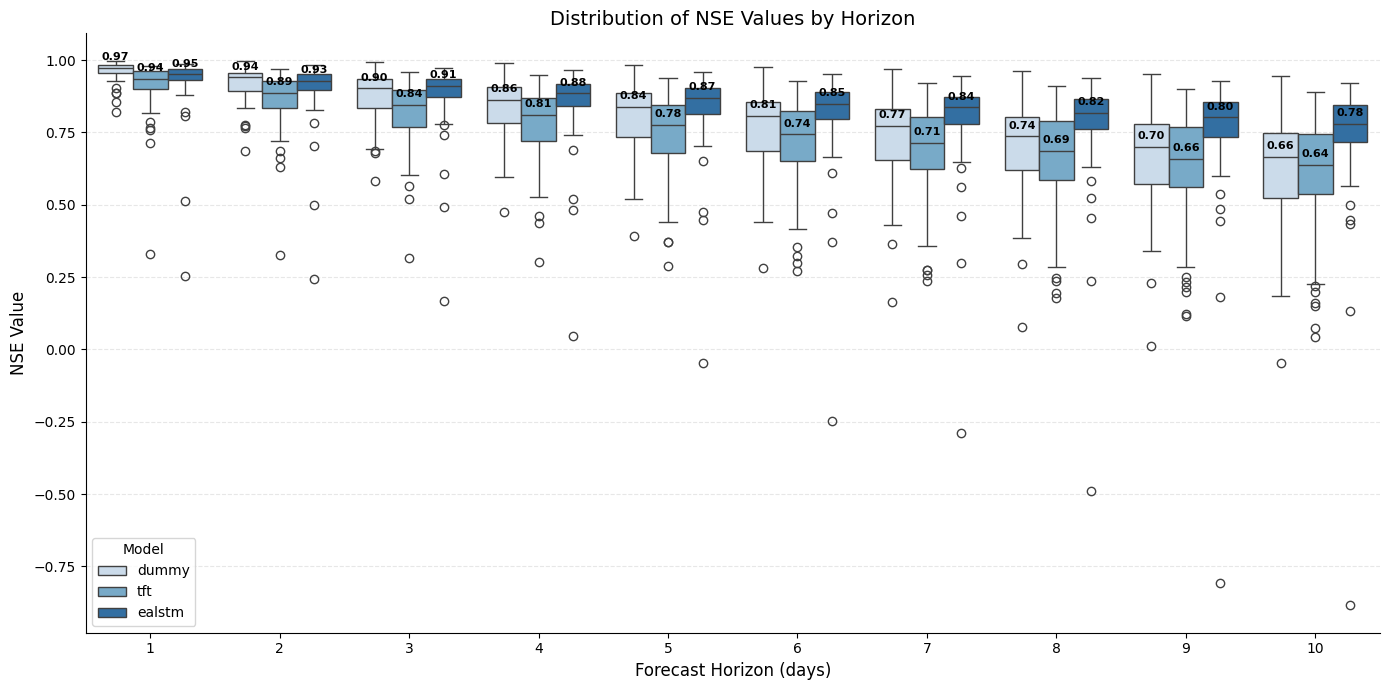

In [32]:
plot_metric_boxplot(
    seasonal_results,
    ["dummy", "tft", "ealstm"],
    metric='NSE',
    palette="Blues",
    individual_points=False
)

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': '1-day Forecast for CA_15044'}, xlabel='Date', ylabel='Streamflow'>)

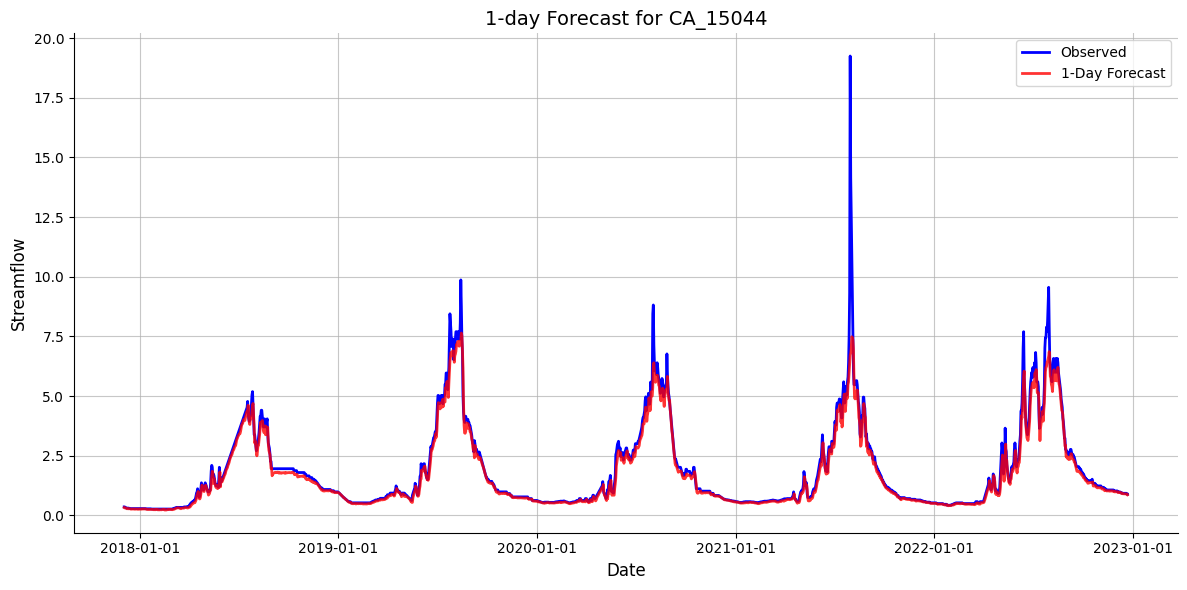

In [25]:
plot_rolling_forecast(
    results["tft"]["df"],
    horizon=1, 
    group_identifier="CA_15044"
)

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': '1-day Forecast for CA_15044'}, xlabel='Date', ylabel='Streamflow'>)

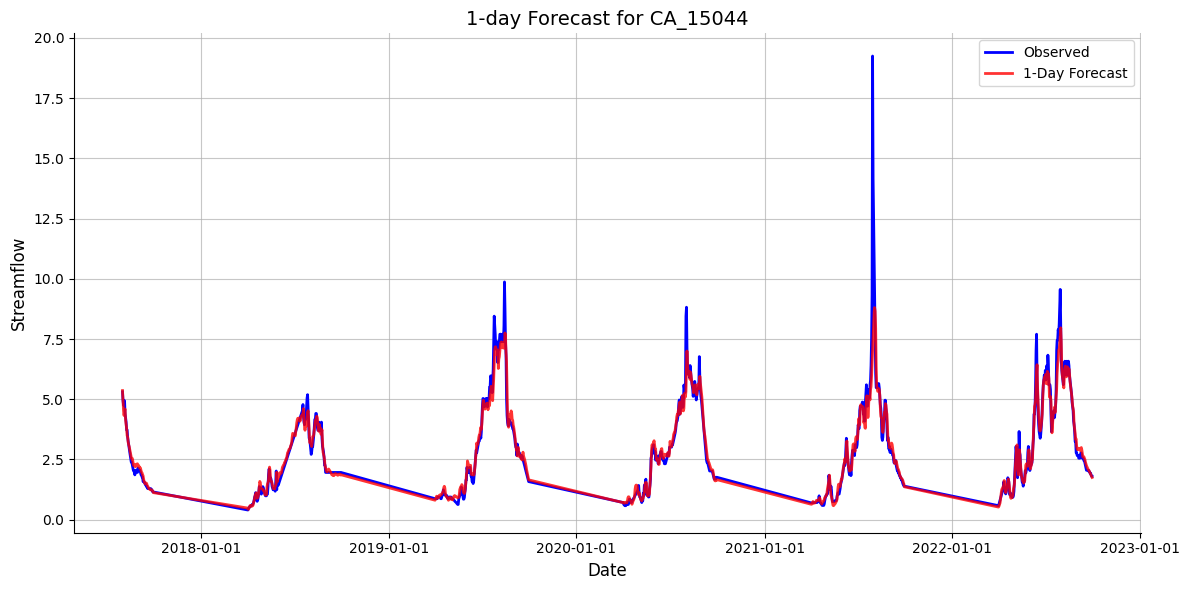

In [27]:
plot_rolling_forecast(
    seasonal_results["ealstm"]["df"],
    horizon=1, 
    group_identifier="CA_15044"
)

(<Figure size 1200x1000 with 2 Axes>,
 <GeoAxes: title={'center': 'NSE at 1-day Horizon for tft'}>)

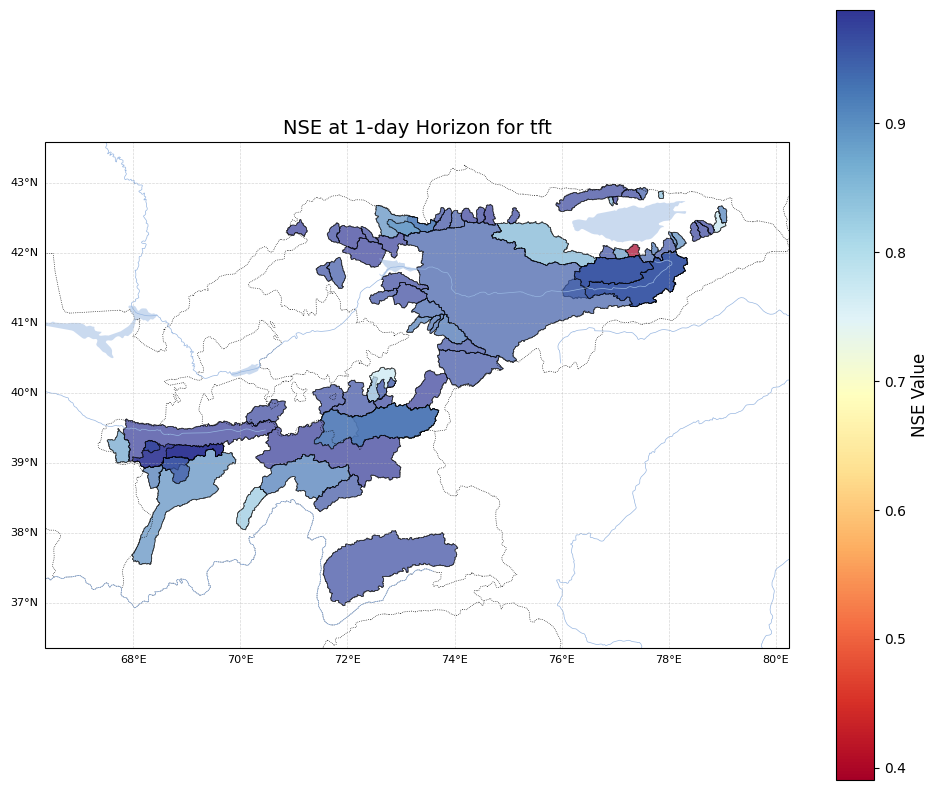

In [28]:
plot_basin_map(
    results,
    'tft',
    caravanify_instance=ca_caravan,

)

(<Figure size 1200x1000 with 2 Axes>,
 <GeoAxes: title={'center': 'NSE at 1-day Horizon for ealstm'}>)

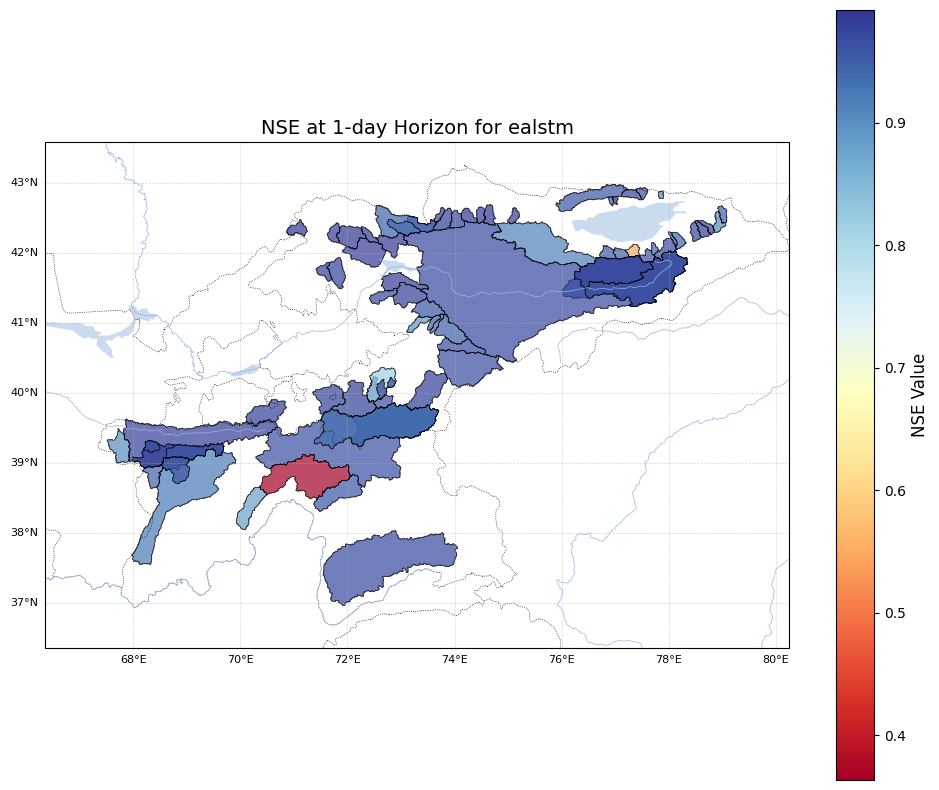

In [29]:
plot_basin_map(
    results,
    'ealstm',
    caravanify_instance=ca_caravan,

)